In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation


## LOad Dataset

In [16]:
df = pd.read_csv("./dataset_oke/dataset_label_lexicon.csv")

df = df.dropna(subset=["clean_text", "label", "aplikasi"])
df["clean_text"] = df["clean_text"].astype(str)
df = df[df["clean_text"].str.strip() != ""]

In [17]:
print("Total data:", len(df))
print("\nDistribusi data per aplikasi:")
print(df["aplikasi"].value_counts())
print("\nDistribusi label per aplikasi:")
print(df.groupby(["aplikasi", "label"]).size())


Total data: 5093

Distribusi data per aplikasi:
aplikasi
bca      1750
livin    1708
brimo    1635
Name: count, dtype: int64

Distribusi label per aplikasi:
aplikasi  label  
bca       negatif    583
          netral     846
          positif    321
brimo     negatif    402
          netral     813
          positif    420
livin     negatif    451
          netral     918
          positif    339
dtype: int64


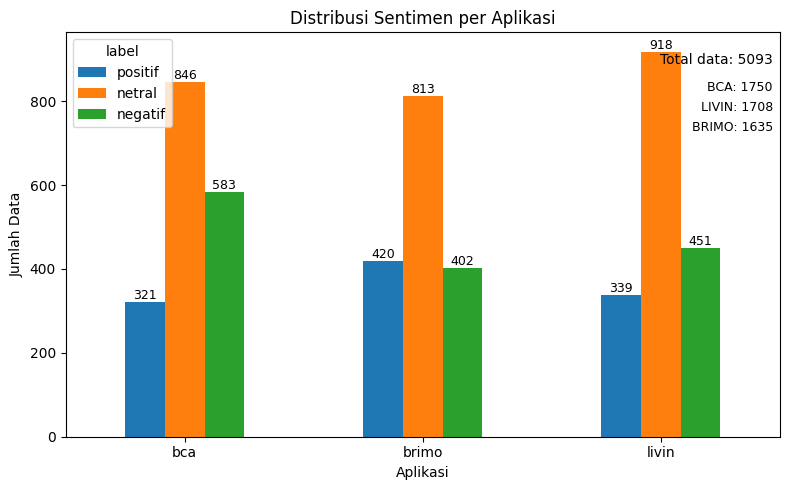

In [18]:


# Pivot sentimen
pivot_sentiment = (
    df.groupby(["aplikasi", "label"])
      .size()
      .unstack(fill_value=0)
)

pivot_sentiment = pivot_sentiment[["positif", "netral", "negatif"]]

# Hitung jumlah
total_data = len(df)
total_per_app = df["aplikasi"].value_counts()

# Plot
ax = pivot_sentiment.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Distribusi Sentimen per Aplikasi")
plt.xlabel("Aplikasi")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)

# Angka di atas bar
for container in ax.containers:
    ax.bar_label(container, label_type="edge", fontsize=9)

# =========================
# TAMBAHAN INFORMASI JUMLAH
# =========================

# Teks jumlah total data
plt.text(
    0.99, 0.95,
    f"Total data: {total_data}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10
)

# Teks jumlah data per aplikasi
y_pos = 0.88
for app, count in total_per_app.items():
    plt.text(
        0.99, y_pos,
        f"{app.upper()}: {count}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9
    )
    y_pos -= 0.05

plt.tight_layout()
plt.show()

## Wordcloud

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def generate_wordcloud(texts, title):
    text = " ".join(texts)

    if not isinstance(text, str) or len(text.split()) == 0:
        print("Skip:", title, "| teks kosong")
        return

    wc = WordCloud(
        width=900,
        height=450,
        background_color="white",
        max_words=200,
        collocations=False,
        min_font_size=6
    ).generate(text)

    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()


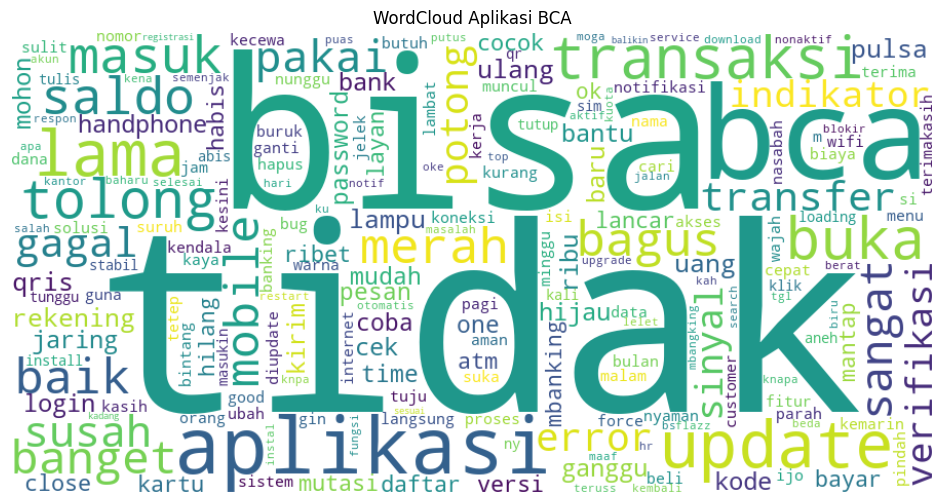

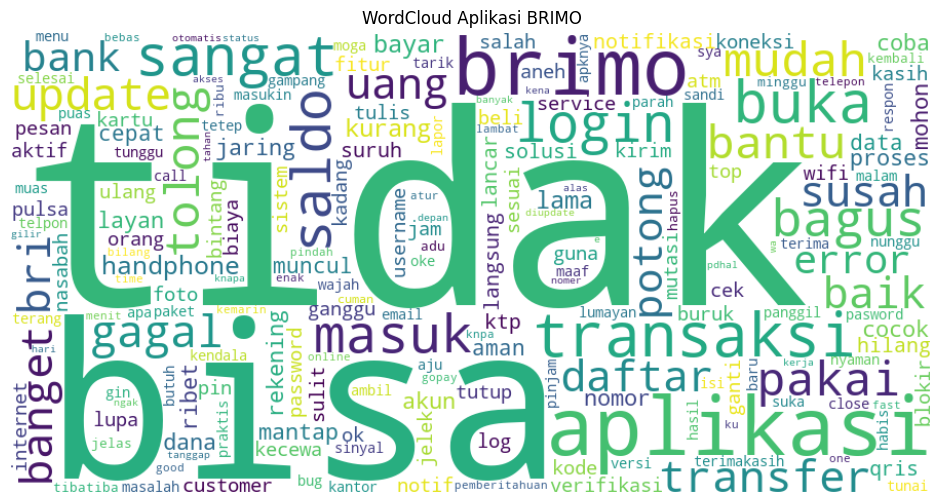

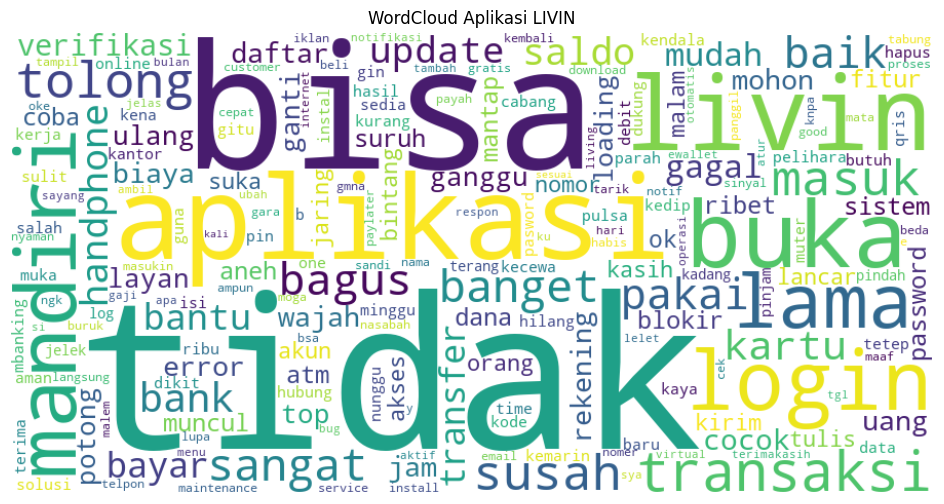

In [20]:
for app in df["aplikasi"].unique():
    texts = df[df["aplikasi"] == app]["clean_text"].dropna().tolist()

    generate_wordcloud(
        texts,
        f"WordCloud Aplikasi {app.upper()}"
    )


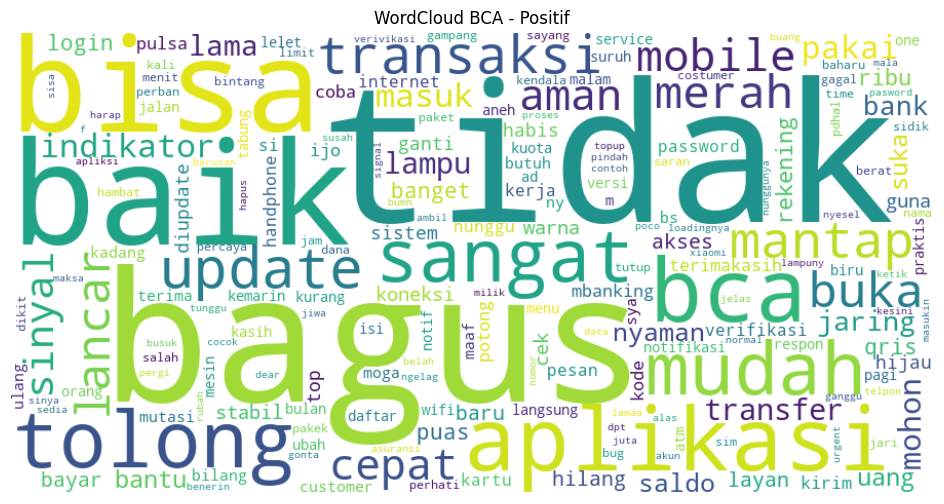

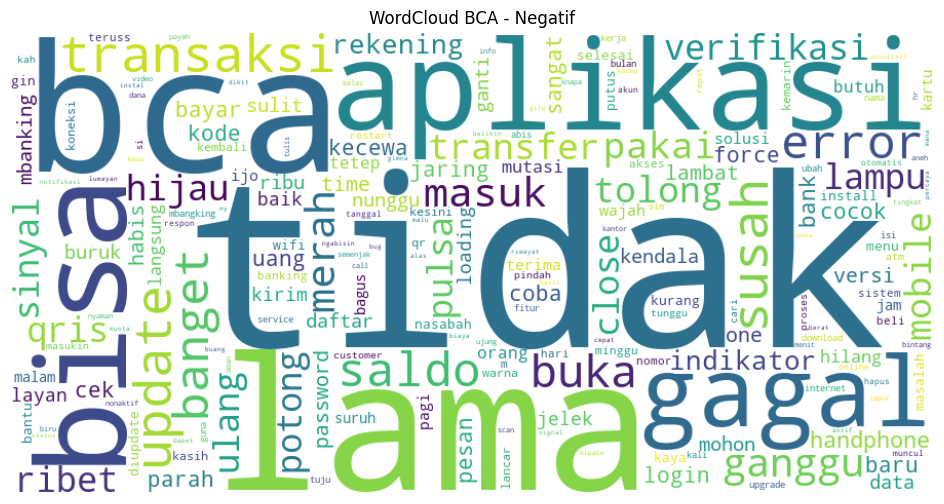

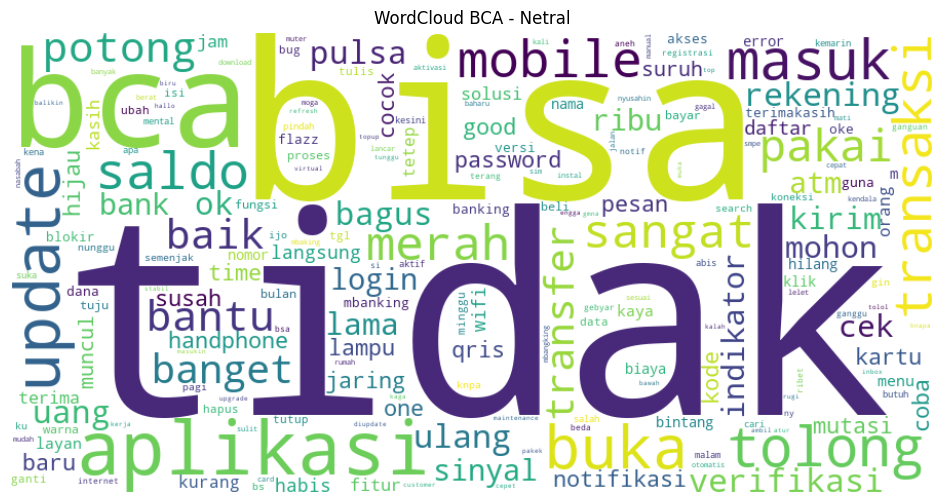

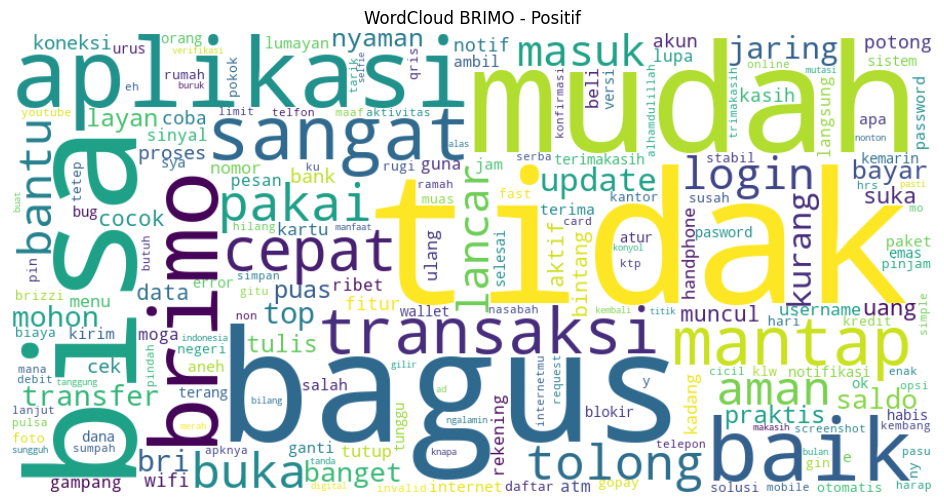

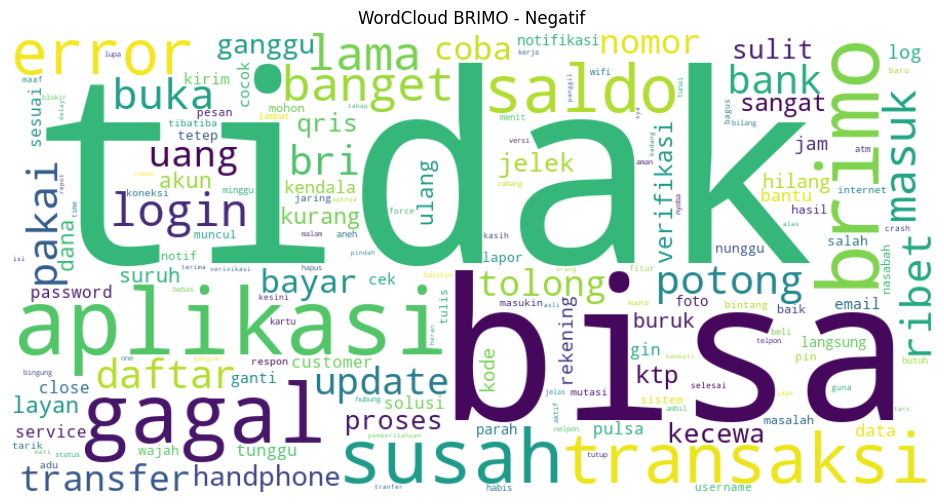

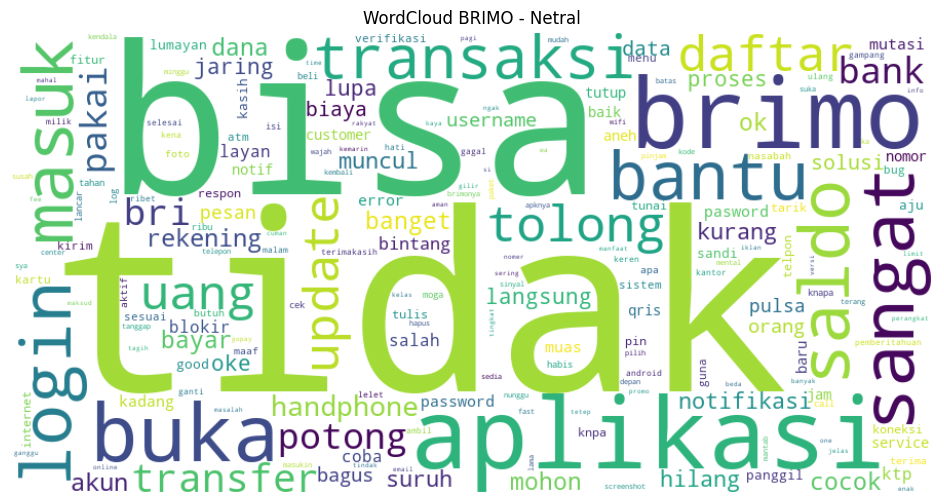

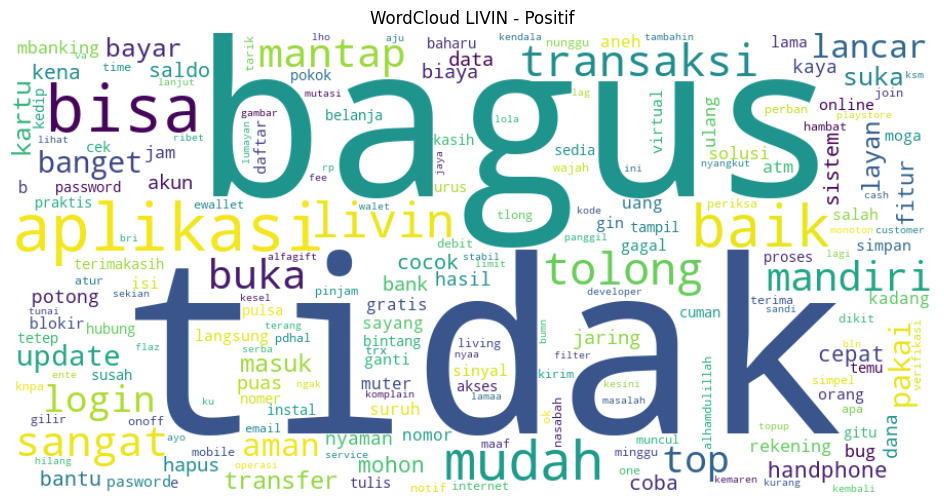

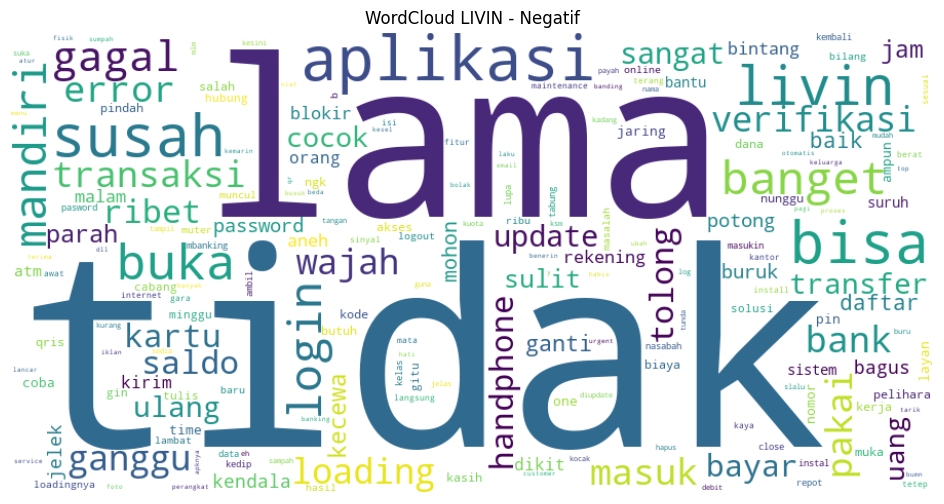

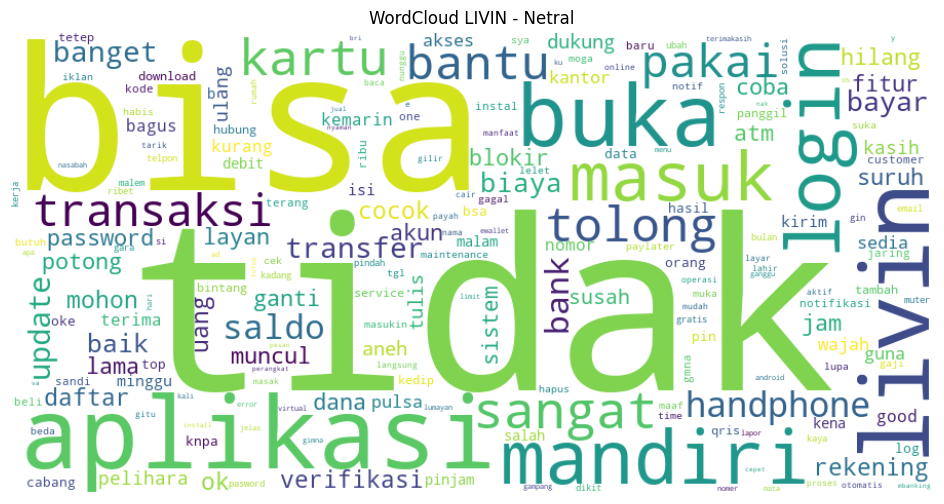

In [21]:
for app in df["aplikasi"].unique():
    subset_app = df[df["aplikasi"] == app]

    for label in ["positif", "negatif", "netral"]:
        texts = subset_app[
            subset_app["label"] == label
        ]["clean_text"].dropna().tolist()

        generate_wordcloud(
            texts,
            f"WordCloud {app.upper()} - {label.capitalize()}"
        )


# Bigram & Trigram BCA 

In [22]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

def plot_ngram_docs(
    texts,
    n=2,
    top_k=10,
    title=""
):
    if len(texts) < 2:
        print("Skip:", title, "| dokumen terlalu sedikit")
        return

    vectorizer = CountVectorizer(
        ngram_range=(n, n),
        token_pattern=r"(?u)\b\w+\b"
    )

    X = vectorizer.fit_transform(texts)

    freqs = X.sum(axis=0).A1
    vocab = vectorizer.get_feature_names_out()

    if len(freqs) == 0:
        print("Skip:", title, "| ngram kosong")
        return

    ngram_freq = sorted(
        zip(vocab, freqs),
        key=lambda x: x[1],
        reverse=True
    )[:top_k]

    labels, values = zip(*ngram_freq)

    plt.figure(figsize=(10, 4))
    plt.barh(labels[::-1], values[::-1])
    plt.xlabel("Frekuensi")
    plt.title(title)
    plt.show()


## BCA

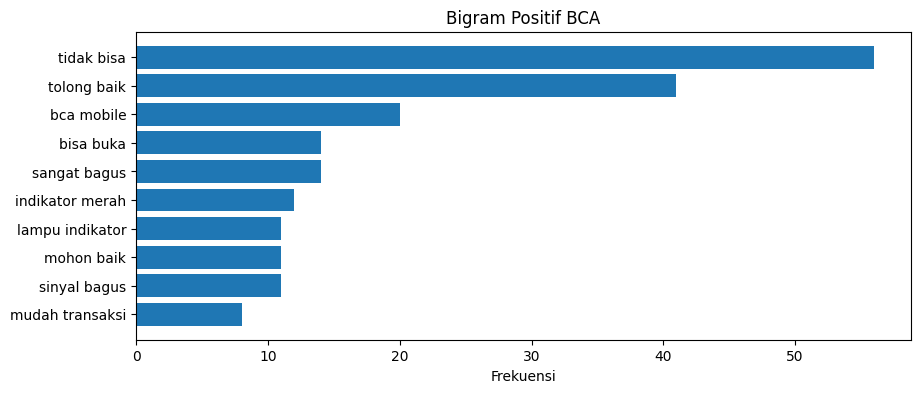

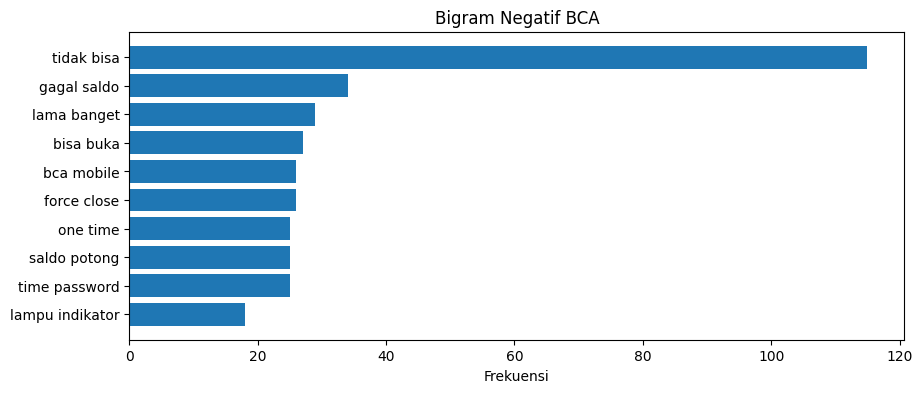

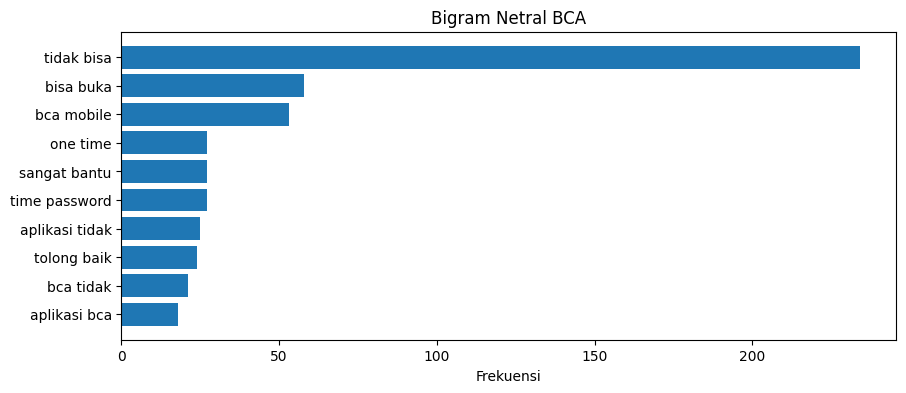

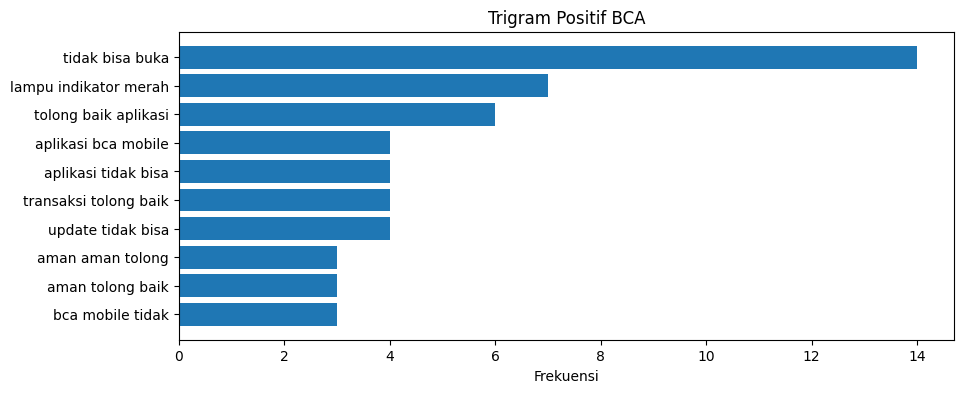

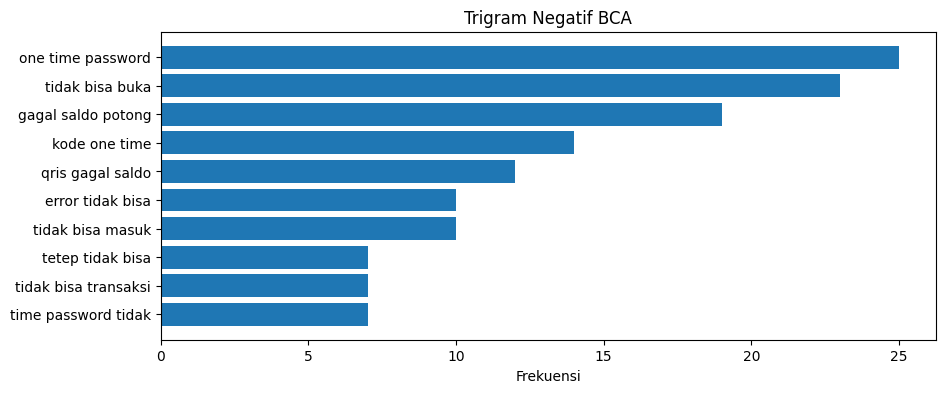

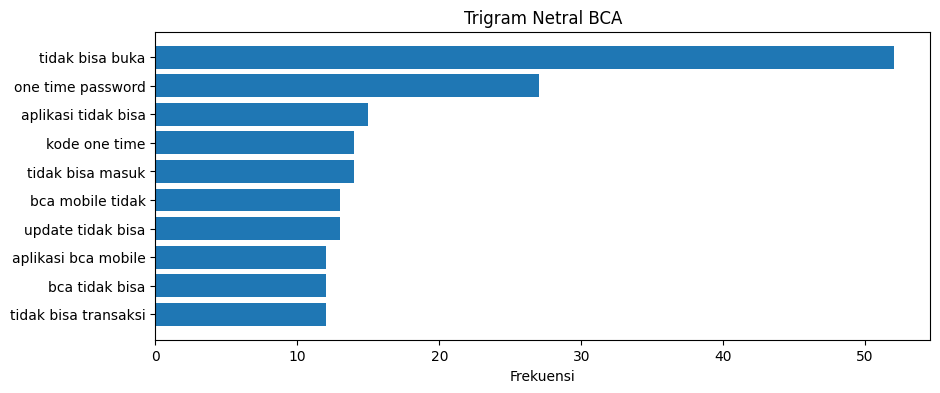

In [23]:
bca = df[df["aplikasi"] == "bca"]

bca_pos = bca[bca["label"] == "positif"]["clean_text"].dropna().tolist()
bca_neg = bca[bca["label"] == "negatif"]["clean_text"].dropna().tolist()
bca_net = bca[bca["label"] == "netral"]["clean_text"].dropna().tolist()

plot_ngram_docs(bca_pos, n=2, title="Bigram Positif BCA")
plot_ngram_docs(bca_neg, n=2, title="Bigram Negatif BCA")
plot_ngram_docs(bca_net, n=2, title="Bigram Netral BCA")

plot_ngram_docs(bca_pos, n=3, title="Trigram Positif BCA")
plot_ngram_docs(bca_neg, n=3, title="Trigram Negatif BCA")
plot_ngram_docs(bca_net, n=3, title="Trigram Netral BCA")

## BRIMO

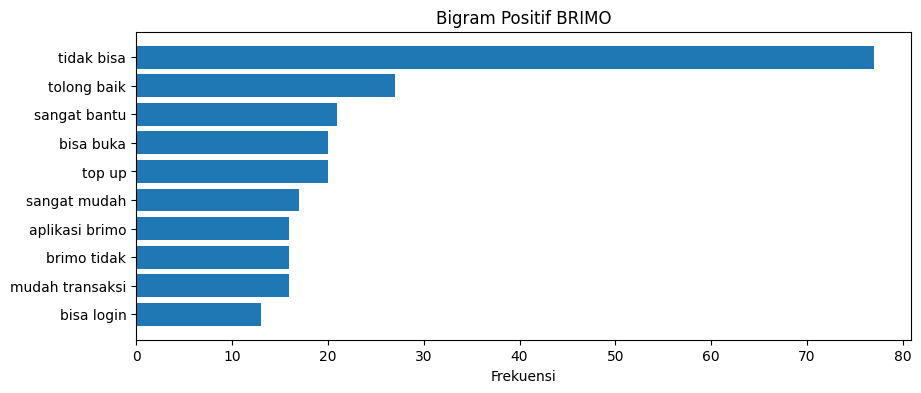

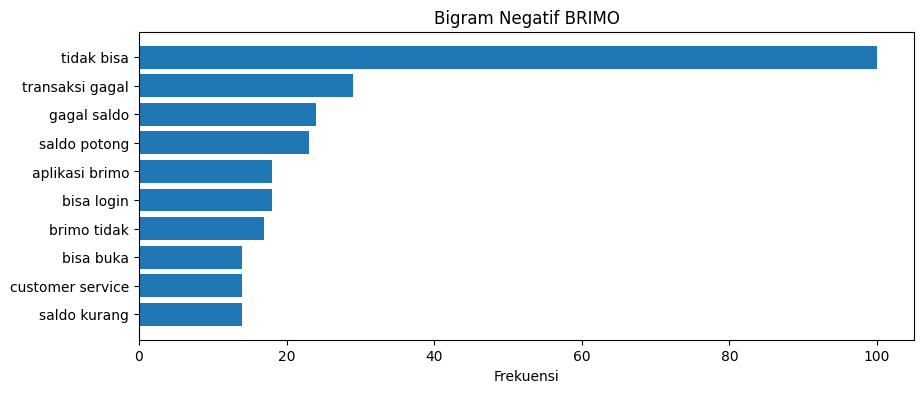

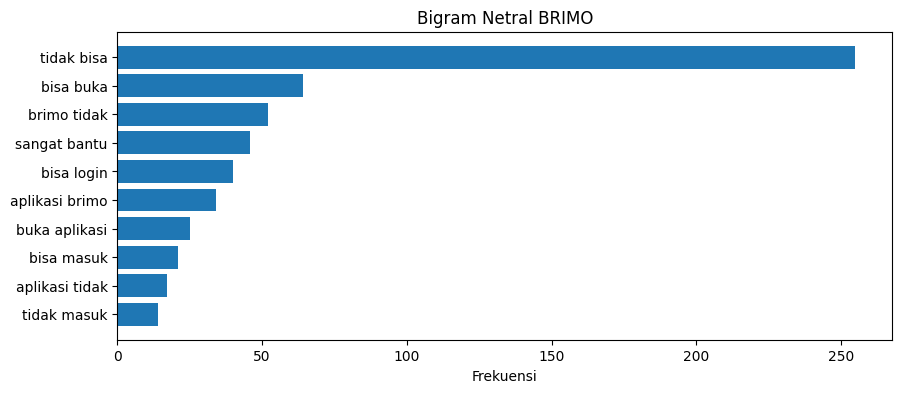

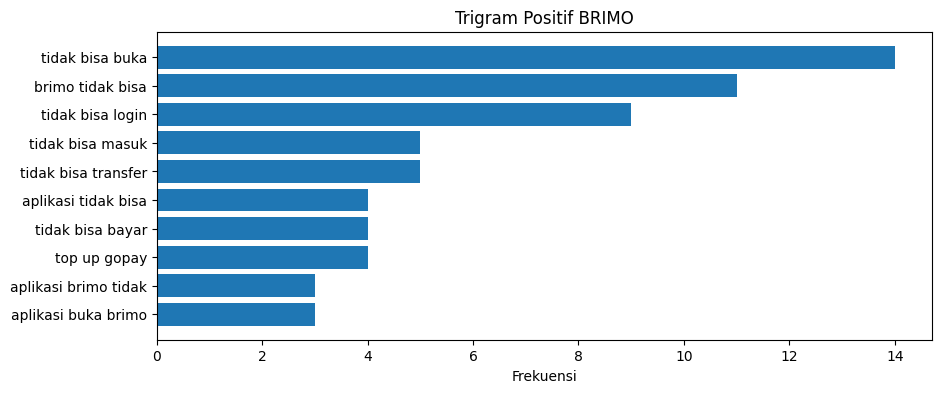

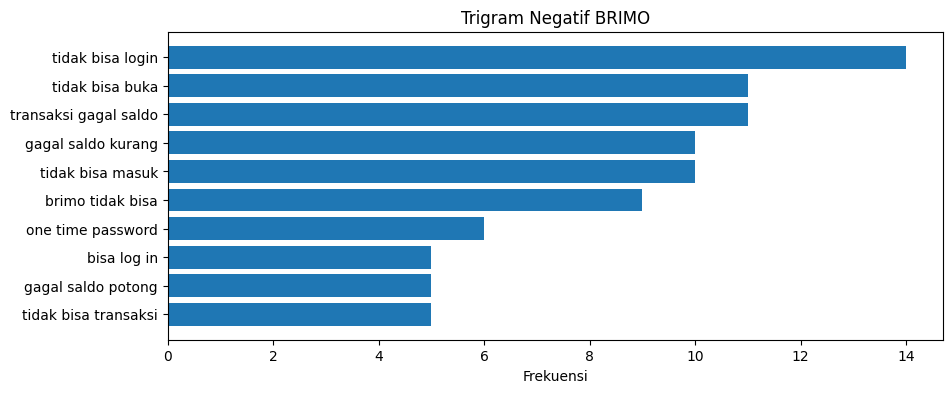

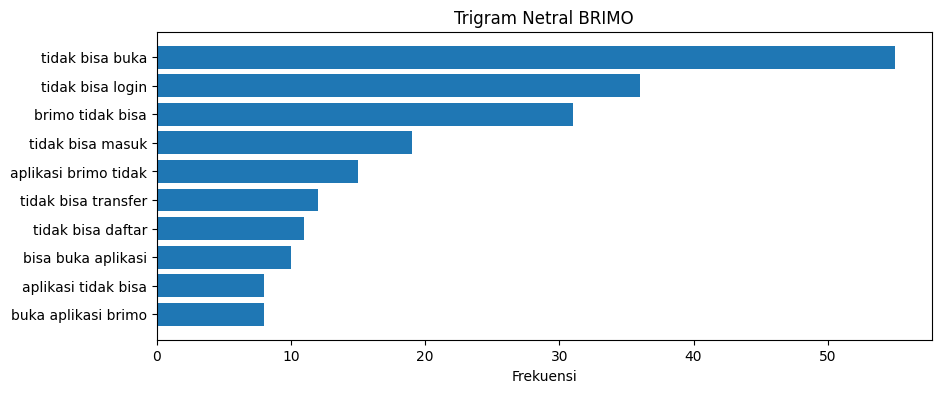

In [24]:
brimo = df[df["aplikasi"] == "brimo"]

brimo_pos = brimo[brimo["label"] == "positif"]["clean_text"].dropna().tolist()
brimo_neg = brimo[brimo["label"] == "negatif"]["clean_text"].dropna().tolist()
brimo_net = brimo[brimo["label"] == "netral"]["clean_text"].dropna().tolist()

plot_ngram_docs(brimo_pos, n=2, title="Bigram Positif BRIMO")
plot_ngram_docs(brimo_neg, n=2, title="Bigram Negatif BRIMO")
plot_ngram_docs(brimo_net, n=2, title="Bigram Netral BRIMO")

plot_ngram_docs(brimo_pos, n=3, title="Trigram Positif BRIMO")
plot_ngram_docs(brimo_neg, n=3, title="Trigram Negatif BRIMO")
plot_ngram_docs(brimo_net, n=3, title="Trigram Netral BRIMO")


## LIVIN

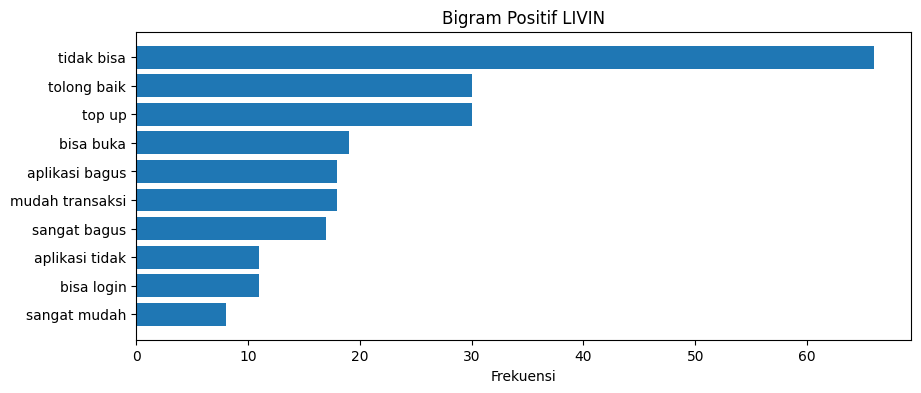

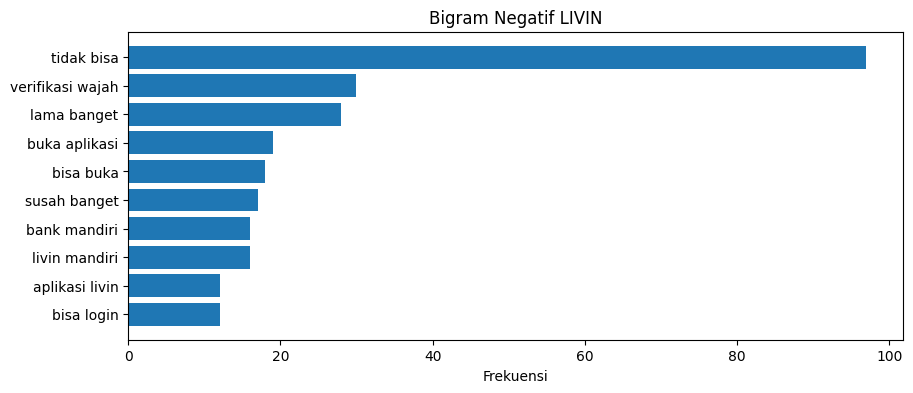

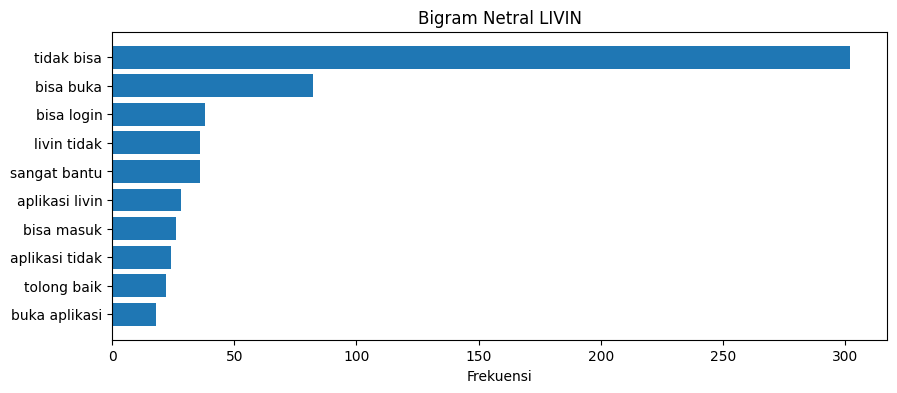

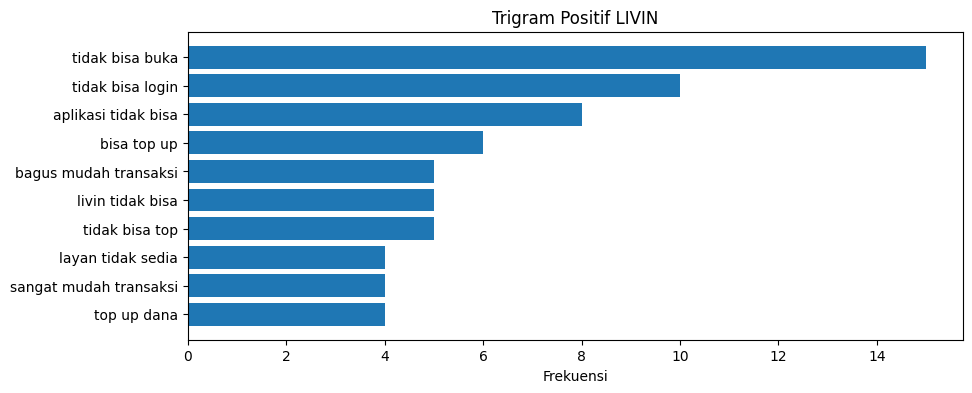

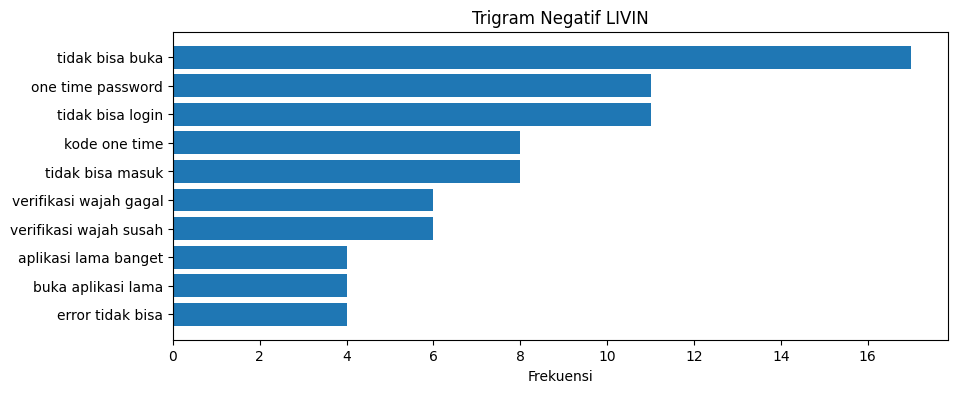

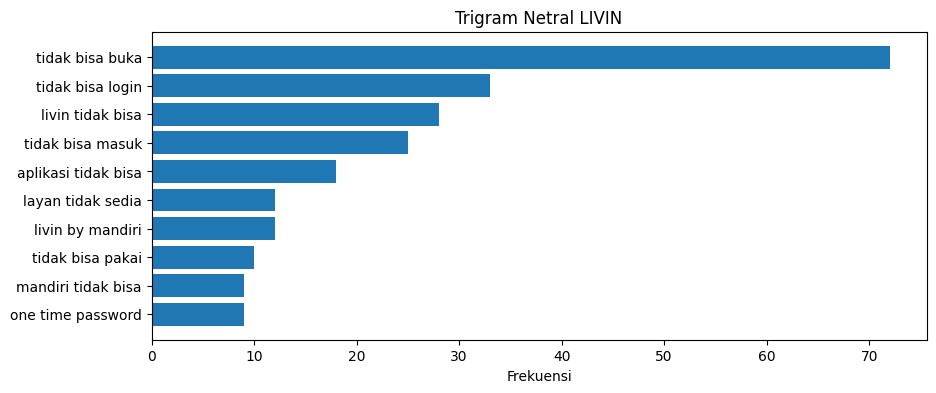

In [28]:
livin = df[df["aplikasi"] == "livin"]

livin_pos = livin[livin["label"] == "positif"]["clean_text"].dropna().tolist()
livin_neg = livin[livin["label"] == "negatif"]["clean_text"].dropna().tolist()
livin_net = livin[livin["label"] == "netral"]["clean_text"].dropna().tolist()

plot_ngram_docs(livin_pos, n=2, title="Bigram Positif LIVIN")
plot_ngram_docs(livin_neg, n=2, title="Bigram Negatif LIVIN")
plot_ngram_docs(livin_net, n=2, title="Bigram Netral LIVIN")

plot_ngram_docs(livin_pos, n=3, title="Trigram Positif LIVIN")
plot_ngram_docs(livin_neg, n=3, title="Trigram Negatif LIVIN")
plot_ngram_docs(livin_net, n=3, title="Trigram Netral LIVIN")

## LDA

In [25]:
def lda_topic_modeling(texts, n_topics=5):
    vectorizer = CountVectorizer(
        max_df=0.95,
        min_df=5
    )
    X = vectorizer.fit_transform(texts)

    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42
    )
    lda.fit(X)

    feature_names = vectorizer.get_feature_names_out()

    topics = []
    for idx, topic in enumerate(lda.components_):
        top_words = [
            feature_names[i]
            for i in topic.argsort()[:-11:-1]
        ]
        topics.append(top_words)

    return topics

In [26]:
for app in df["aplikasi"].unique():
    print(f"\n===== TOPIK LDA APLIKASI {app.upper()} =====")
    
    texts = df[df["aplikasi"] == app]["clean_text"]
    topics = lda_topic_modeling(texts, n_topics=5)

    for i, topic in enumerate(topics):
        print(f"Topik {i+1}: {', '.join(topic)}")



===== TOPIK LDA APLIKASI BCA =====
Topik 1: lama, merah, update, aplikasi, indikator, lampu, tidak, transaksi, hijau, banget
Topik 2: sangat, bantu, mudah, mantap, ok, transfer, bagus, transaksi, layan, rekening
Topik 3: bisa, tidak, aplikasi, bca, buka, update, mobile, baik, tolong, mohon
Topik 4: tidak, saldo, bca, potong, uang, gagal, qris, transaksi, rekening, masuk
Topik 5: bagus, tidak, pulsa, masuk, verifikasi, kode, password, one, time, pesan

===== TOPIK LDA APLIKASI BRIMO =====
Topik 1: sangat, mudah, bantu, mantap, cepat, transaksi, up, top, gampang, puas
Topik 2: brimo, potong, tidak, rekening, bintang, bank, error, aplikasi, transfer, layan
Topik 3: saldo, tidak, gagal, transaksi, uang, bri, potong, bayar, qris, masuk
Topik 4: tidak, bisa, aplikasi, brimo, masuk, daftar, login, handphone, tolong, baik
Topik 5: tidak, bisa, aplikasi, buka, brimo, bagus, login, banget, update, transfer

===== TOPIK LDA APLIKASI LIVIN =====
Topik 1: tidak, bisa, login, transfer, error, livin

In [27]:
for app in df["aplikasi"].unique():
    for label in df["label"].unique():
        print(f"\n--- LDA {app.upper()} | {label} ---")
        
        texts = df[
            (df["aplikasi"] == app) &
            (df["label"] == label)
        ]["clean_text"]

        topics = lda_topic_modeling(texts, n_topics=3)

        for i, topic in enumerate(topics):
            print(f"Topik {i+1}: {', '.join(topic)}")


--- LDA BCA | netral ---
Topik 1: sangat, bantu, ulang, verifikasi, ok, pulsa, atm, login, tidak, aplikasi
Topik 2: tidak, bisa, bca, aplikasi, buka, tolong, masuk, update, saldo, mobile
Topik 3: tidak, bisa, merah, update, transaksi, bca, transfer, pakai, indikator, sinyal

--- LDA BCA | negatif ---
Topik 1: tidak, bisa, aplikasi, bca, error, buka, susah, verifikasi, ganggu, ulang
Topik 2: lama, update, merah, aplikasi, banget, lampu, sinyal, hijau, indikator, transaksi
Topik 3: gagal, saldo, bca, tidak, masuk, transaksi, qris, potong, pulsa, uang

--- LDA BCA | positif ---
Topik 1: tidak, mudah, bisa, masuk, bca, transfer, cepat, saldo, baik, uang
Topik 2: bagus, sangat, sinyal, puas, merah, lampu, jaring, kadang, banget, update
Topik 3: baik, aplikasi, tidak, tolong, bca, update, mantap, bisa, lancar, buka

--- LDA BRIMO | netral ---
Topik 1: tidak, aplikasi, bisa, brimo, buka, update, bank, masuk, muncul, pakai
Topik 2: tidak, bisa, sangat, login, bantu, daftar, handphone, masuk, 